# Does the LETKF write a cloud-water increment in experiment 805?

`inc(T)` in a KENDA-CH1 cycle carries `T`, `QV`, `QC`, `U`, `V`, `P` and `W_SO`. `QC` is
not an assimilated variable, so its increment is expected to be identically zero; other
results suggest it may not be. This notebook reads every `QC` increment of the 805 period
and reports, per cycle and per model level, how much of it is actually non-zero and how
large it is.

Reference scales for judging "large": nothing to compare against inside `inc` itself, so
each cycle's `QC` increment is also compared against the `QC` field of the same cycle's
first guess `lff(T)` (the state the increment is added to) and against the `QV` increment.

In [1]:
import os
os.environ["ECCODES_VERSION_CHECK_OFF"] = "1"  # must be set before importing earthkit.data

import pickle
from datetime import datetime
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import eccodes            # before earthkit.data: fixes native library resolution
import earthkit.data as ekd

SAVE_FIGURES = False
OUTPUT_DIR = Path("./figures/qc_increment_805")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def finish(fig, name):
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / name, dpi=150, bbox_inches="tight")
    plt.show()

In [2]:
# ============================== what to analyse ==============================
EXP_ID = "805"
BASE_DIR_TMPL = "/store_new/mch/msopr/jdelbeke/ICON_TST/{exp}"
YEAR_SUFFIX = "25"

# On disk for 805: inc 2025-10-04 00 UTC .. 2025-10-10 01 UTC (146 files).
# lff starts one hour later, so the comparison against the first guess starts at 01 UTC.
DATE_START = datetime(2025, 10, 4, 0)
DATE_END = datetime(2025, 10, 10, 1)
CYCLE_TIMES = pd.date_range(DATE_START, DATE_END, freq="1h").to_pydatetime().tolist()

N_WORKERS = 16
LEVELS = list(range(1, 81))          # every model level; QC increments carry all 80
GROUND_LEVEL = 80

# Same Swiss box the other notebooks use, for the "is it only over Switzerland" split.
ANALYSIS_BOX = dict(lon=(5.9, 10.6), lat=(45.8, 47.9))

# Below this, a value is treated as a rounding artefact of GRIB packing rather than a real
# increment. Set from the packing precision actually found, printed in the next cell.
ZERO_TOL = 0.0                       # 0.0 = "non-zero" means literally != 0

EXP_COLOUR = "#009E73"               # 805; 801/802 own #0072B2/#D55E00
print(f"{len(CYCLE_TIMES)} cycles, {DATE_START:%Y-%m-%d %H} - {DATE_END:%Y-%m-%d %H} UTC")

146 cycles, 2025-10-04 00 - 2025-10-10 01 UTC


In [3]:
# ====================== GRIB reader (as in the decomposition notebook) ======================
def file_path(exp_id, kind, time):
    """kind: "lff"/"iff" (first-guess archive) or "inc"/"iaf"/"laf" (analysis archive)."""
    base = BASE_DIR_TMPL.format(exp=exp_id)
    sub = ("FG" if kind in ("lff", "iff") else "ANA") + YEAR_SUFFIX
    return os.path.join(base, sub, "det", f"{kind}{time:%Y%m%d%H}")


CACHE_DIR = Path(f"/scratch/mch/{os.environ['USER']}/spindown_grib_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def build_index(path):
    """shortName -> [(level, byte offset, byte length), ...], sorted by level."""
    index = {}
    with open(path, "rb") as f:
        while True:
            h = eccodes.codes_grib_new_from_file(f, headers_only=True)
            if h is None:
                break
            index.setdefault(eccodes.codes_get(h, "shortName"), []).append(
                (eccodes.codes_get_long(h, "level"),
                 eccodes.codes_get_message_offset(h),
                 eccodes.codes_get_long(h, "totalLength")))
            eccodes.codes_release(h)
    for entries in index.values():
        entries.sort()
    return index


def load_index(path):
    """build_index, cached on disk, keyed by (name, size, mtime)."""
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    stat = os.stat(path)
    cached = CACHE_DIR / f"{Path(path).name}_{stat.st_size}_{stat.st_mtime_ns}.pkl"
    if cached.exists():
        with open(cached, "rb") as fh:
            return pickle.load(fh)
    index = build_index(path)
    tmp = cached.with_suffix(f".tmp{os.getpid()}")
    with open(tmp, "wb") as fh:
        pickle.dump(index, fh, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(tmp, cached)
    return index


_grid = None


def grid_lonlat(path):
    """Cell longitudes and latitudes, cached in an .npz. All files share the same grid."""
    global _grid
    if _grid is not None:
        return _grid
    npz = CACHE_DIR / "icon_grid_lonlat.npz"
    if npz.exists():
        z = np.load(npz)
        _grid = (z["lon"], z["lat"])
    else:
        xa = ekd.from_source("file", path).to_fieldlist()[0].to_xarray()
        _grid = (xa["longitude"].values, xa["latitude"].values)
        np.savez(npz, lon=_grid[0], lat=_grid[1])
    return _grid


class Grib:
    """One GRIB file, indexed by variable name, decoding only the messages asked for."""

    def __init__(self, path):
        self.path = path
        self.index = load_index(path)

    def _read(self, entries):
        values = []
        with open(self.path, "rb") as f:
            for _, offset, length in entries:
                f.seek(offset)
                h = eccodes.codes_new_from_message(f.read(length))
                values.append(eccodes.codes_get_values(h))
                eccodes.codes_release(h)
        return np.array([e[0] for e in entries]), np.stack(values)

    def profile(self, short_name, levels=None):
        entries = self.index[short_name]
        if levels is not None:
            want = {int(lev) for lev in levels}
            entries = [e for e in entries if e[0] in want]
        return self._read(entries)

    def field(self, short_name):
        return self._read(self.index[short_name][:1])[1][0]

    @property
    def lonlat(self):
        return grid_lonlat(self.path)


def in_box(lon, lat, box):
    return ((lon >= box["lon"][0]) & (lon <= box["lon"][1]) &
            (lat >= box["lat"][0]) & (lat <= box["lat"][1]))

## 1. One file first

Before reading six days of files: what does a single `QC` increment look like, and what is
the GRIB packing precision? The packing step sets the floor below which "non-zero" means
nothing — a field of exact zeros packs to exact zeros, but a field that went through any
arithmetic can come back with values at the quantisation step.

In [4]:
probe_t = CYCLE_TIMES[len(CYCLE_TIMES) // 2]
probe = Grib(file_path(EXP_ID, "inc", probe_t))
print(f"{file_path(EXP_ID, 'inc', probe_t)}")
print("variables:", {k: len(v) for k, v in sorted(probe.index.items())})

_, qc_inc = probe.profile("QC", LEVELS)
lon, lat = probe.lonlat
print(f"\nQC increment array {qc_inc.shape} (levels x cells)")
print(f"  exactly zero:       {np.mean(qc_inc == 0):.4%} of values")
print(f"  min / max:          {qc_inc.min():.3e} / {qc_inc.max():.3e} kg/kg")
print(f"  mean / rms:         {qc_inc.mean():.3e} / {np.sqrt(np.mean(qc_inc**2)):.3e} kg/kg")

nz = np.abs(qc_inc[qc_inc != 0])
if nz.size:
    print(f"  smallest non-zero magnitude: {nz.min():.3e} kg/kg")
    # The packing step: distinct values are multiples of it, so consecutive differences
    # of the sorted unique values expose it.
    uniq = np.unique(np.abs(qc_inc))
    step = np.min(np.diff(uniq)) if uniq.size > 1 else np.nan
    print(f"  smallest gap between distinct magnitudes (packing step): {step:.3e} kg/kg")
    print(f"  percentiles of |non-zero|: "
          + ", ".join(f"p{p}={np.percentile(nz, p):.2e}" for p in (50, 90, 99, 99.9)))
else:
    print("  the whole field is exactly zero")

/store_new/mch/msopr/jdelbeke/ICON_TST/805/ANA25/det/inc2025100701
variables: {'P': 80, 'QC': 80, 'QV': 80, 'T': 80, 'U': 80, 'V': 80, 'W_SO': 8}



QC increment array (80, 1147980) (levels x cells)
  exactly zero:       55.0341% of values


  min / max:          -7.544e-04 / 2.062e-03 kg/kg


  mean / rms:         7.253e-07 / 1.589e-05 kg/kg


  smallest non-zero magnitude: 2.910e-11 kg/kg


  smallest gap between distinct magnitudes (packing step): 7.276e-12 kg/kg


  percentiles of |non-zero|: p50=6.55e-09, p90=5.93e-07, p99=9.09e-05, p99.9=3.20e-04


## 2. Every cycle

Per cycle and per model level, on the full domain and on the Swiss box separately:
how many cells are non-zero, the mean (signed, so cancellation shows), the RMS, and the
extremes. `QV`'s increment and `lff`'s own `QC` come along as yardsticks.

In [5]:
_BOX = None


def _init_worker(box_mask):
    global _BOX
    _BOX = box_mask


def cycle_stats(t):
    """One cycle reduced to per-level statistics of the QC increment, plus yardsticks."""
    inc = Grib(file_path(EXP_ID, "inc", t))
    lev, qc = inc.profile("QC", LEVELS)
    _, qv = inc.profile("QV", LEVELS)
    box = _BOX

    # lff(T) is the state the increment lands on; absent for the very first cycle.
    try:
        qc_fg = Grib(file_path(EXP_ID, "lff", t)).profile("QC", LEVELS)[1]
    except FileNotFoundError:
        qc_fg = None

    hit = np.abs(qc) > ZERO_TOL
    out = dict(time=t, hour=t.hour, level=lev,
               n_cells=qc.shape[1], n_box_cells=int(box.sum()))
    for tag, sel in (("dom", slice(None)), ("box", box)):
        a, b = qc[:, sel], qv[:, sel]
        c = None if qc_fg is None else qc_fg[:, sel]
        h = hit[:, sel]
        out[f"frac_nonzero_{tag}"] = h.mean(axis=1)
        out[f"mean_{tag}"] = a.mean(axis=1)
        out[f"rms_{tag}"] = np.sqrt((a ** 2).mean(axis=1))
        out[f"min_{tag}"] = a.min(axis=1)
        out[f"max_{tag}"] = a.max(axis=1)
        out[f"absmean_{tag}"] = np.abs(a).mean(axis=1)
        out[f"qv_rms_{tag}"] = np.sqrt((b ** 2).mean(axis=1))
        # no first guess at the first cycle: left as NaN rather than a fabricated zero
        out[f"fg_qc_mean_{tag}"] = np.full(a.shape[0], np.nan) if c is None else c.mean(axis=1)
        out[f"fg_qc_rms_{tag}"] = (np.full(a.shape[0], np.nan) if c is None
                                   else np.sqrt((c ** 2).mean(axis=1)))
    return out


def cycle_stats_safe(t):
    try:
        return cycle_stats(t)
    except Exception as e:
        print(f"  skipped {t:%Y-%m-%d %H}: {type(e).__name__}: {e}", flush=True)
        return None


lon, lat = grid_lonlat(file_path(EXP_ID, "inc", CYCLE_TIMES[0]))
box_mask = in_box(lon, lat, ANALYSIS_BOX)
print(f"reading {len(CYCLE_TIMES)} cycles on {N_WORKERS} workers "
      f"({lon.size} cells, {box_mask.sum()} inside the Swiss box)")

with ProcessPoolExecutor(max_workers=N_WORKERS, initializer=_init_worker,
                         initargs=(box_mask,)) as ex:
    records = [r for r in ex.map(cycle_stats_safe, CYCLE_TIMES) if r is not None]

levels = records[0]["level"]
# Long form: one row per (cycle, level), which every table and plot below slices from.
stats = pd.DataFrame([
    {"time": r["time"], "hour": r["hour"], "level": int(lv),
     **{k: r[k][i] for k in r if k.endswith(("_dom", "_box"))}}
    for r in records for i, lv in enumerate(levels)
])
stats.to_csv(OUTPUT_DIR / "qc_increment_stats_805.csv", index=False)
print(f"done: {len(records)} cycles x {len(levels)} levels = {len(stats)} rows")

reading 146 cycles on 16 workers (1147980 cells, 80876 inside the Swiss box)


done: 146 cycles x 80 levels = 11680 rows


## 3. The answer

The one number the question asks for, then the detail behind it.

In [6]:
tot = stats["frac_nonzero_dom"].mean()
per_cycle = stats.groupby("time").agg(frac=("frac_nonzero_dom", "mean"),
                                      amax=("max_dom", "max"), amin=("min_dom", "min"),
                                      rms=("rms_dom", lambda s: np.sqrt((s ** 2).mean())))
n_clean = int((per_cycle["frac"] == 0).sum())

print(f"QC increment, experiment {EXP_ID}, {len(per_cycle)} cycles")
print(f"  cycles with an identically zero QC increment: {n_clean}/{len(per_cycle)}")
print(f"  fraction of all (level, cell) values non-zero: {tot:.4%}")
print(f"  largest positive / most negative increment:    "
      f"{per_cycle['amax'].max():+.3e} / {per_cycle['amin'].min():+.3e} kg/kg")
print(f"  domain RMS over everything:                    "
      f"{np.sqrt((stats['rms_dom'] ** 2).mean()):.3e} kg/kg")
print(f"  same, Swiss box only:                          "
      f"{np.sqrt((stats['rms_box'] ** 2).mean()):.3e} kg/kg")

# Size relative to the field it modifies: an increment 1e-3 of the first guess is noise,
# one of order 1 rewrites the cloud.
_fg = stats["fg_qc_rms_dom"]
_ratio = (stats["rms_dom"] / _fg.where(_fg > 0)).dropna()
if len(_ratio):
    print(f"\n  QC increment RMS as a fraction of the first-guess QC RMS: "
          f"median {_ratio.median():.3%}, p95 {_ratio.quantile(0.95):.3%}, "
          f"max {_ratio.max():.3%}")

print("\nworst ten cycles by domain RMS:")
print(per_cycle.sort_values("rms", ascending=False).head(10).to_string(
    float_format=lambda v: f"{v:.3e}"))

QC increment, experiment 805, 146 cycles
  cycles with an identically zero QC increment: 0/146
  fraction of all (level, cell) values non-zero: 43.3627%
  largest positive / most negative increment:    +5.316e-03 / -2.937e-03 kg/kg
  domain RMS over everything:                    2.409e-05 kg/kg
  same, Swiss box only:                          2.816e-05 kg/kg

  QC increment RMS as a fraction of the first-guess QC RMS: median 44.266%, p95 116.222%, max 2446897195032404992.000%

worst ten cycles by domain RMS:
                         frac      amax       amin       rms
time                                                        
2025-10-04 15:00:00 3.377e-01 2.981e-03 -1.927e-03 5.361e-05
2025-10-04 14:00:00 4.031e-01 2.646e-03 -1.704e-03 5.023e-05
2025-10-04 16:00:00 4.564e-01 3.927e-03 -1.883e-03 4.995e-05
2025-10-04 17:00:00 3.855e-01 3.524e-03 -1.438e-03 4.897e-05
2025-10-04 18:00:00 4.282e-01 3.905e-03 -1.615e-03 4.849e-05
2025-10-04 12:00:00 4.509e-01 2.547e-03 -1.908e-03 4.490e-

In [7]:
# Where in the vertical, and how it splits between domain and the Swiss box.
by_level = stats.groupby("level").agg(
    frac_nonzero_dom=("frac_nonzero_dom", "mean"),
    frac_nonzero_box=("frac_nonzero_box", "mean"),
    mean_dom=("mean_dom", "mean"),
    rms_dom=("rms_dom", lambda s: np.sqrt((s ** 2).mean())),
    rms_box=("rms_box", lambda s: np.sqrt((s ** 2).mean())),
    qv_rms_dom=("qv_rms_dom", lambda s: np.sqrt((s ** 2).mean())),
    fg_qc_rms_dom=("fg_qc_rms_dom", "mean"),
    max_dom=("max_dom", "max"), min_dom=("min_dom", "min"))

active = by_level[by_level["frac_nonzero_dom"] > 0]
print(f"levels with any non-zero QC increment: {len(active)} of {len(by_level)}"
      + (f" (levels {active.index.min()}-{active.index.max()})" if len(active) else ""))
print("\nten levels with the largest QC increment RMS:")
print(by_level.sort_values("rms_dom", ascending=False).head(10).to_string(
    float_format=lambda v: f"{v:.3e}"))

levels with any non-zero QC increment: 79 of 80 (levels 2-80)

ten levels with the largest QC increment RMS:
       frac_nonzero_dom  frac_nonzero_box  mean_dom   rms_dom   rms_box  qv_rms_dom  fg_qc_rms_dom   max_dom    min_dom
level                                                                                                                  
61            6.652e-01         6.761e-01 2.824e-06 4.574e-05 4.731e-05   1.882e-04      1.004e-04 2.941e-03 -2.233e-03
60            6.292e-01         6.465e-01 2.782e-06 4.565e-05 4.933e-05   1.881e-04      1.024e-04 3.077e-03 -1.667e-03
62            6.113e-01         6.243e-01 2.701e-06 4.525e-05 4.596e-05   1.883e-04      9.781e-05 3.090e-03 -2.133e-03
59            6.716e-01         6.932e-01 2.682e-06 4.497e-05 5.086e-05   1.866e-04      1.024e-04 3.065e-03 -1.852e-03
57            6.856e-01         7.050e-01 2.321e-06 4.477e-05 5.096e-05   1.815e-04      1.022e-04 3.927e-03 -2.196e-03
58            6.863e-01         7.041e-01 2.534e-06

## 4. Figures

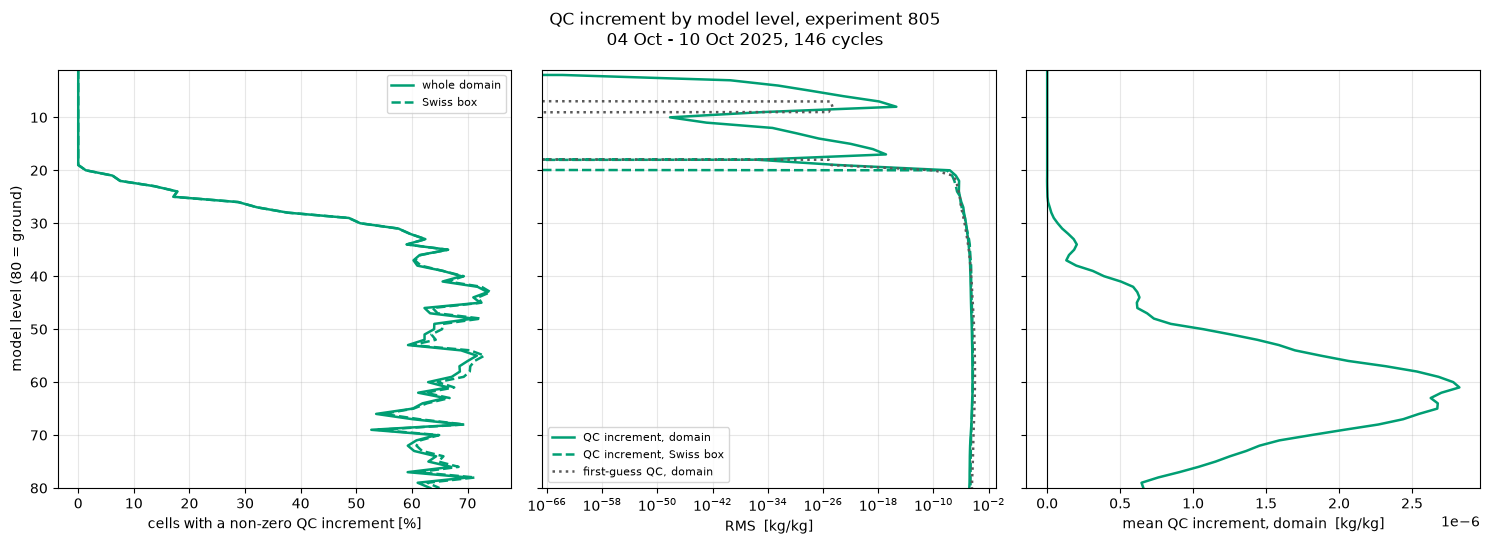

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)

ax = axes[0]
ax.plot(by_level["frac_nonzero_dom"] * 100, by_level.index, "-", color=EXP_COLOUR,
        lw=1.8, label="whole domain")
ax.plot(by_level["frac_nonzero_box"] * 100, by_level.index, "--", color=EXP_COLOUR,
        lw=1.8, label="Swiss box")
ax.set_xlabel("cells with a non-zero QC increment [%]")
ax.set_ylabel("model level (80 = ground)")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(by_level["rms_dom"], by_level.index, "-", color=EXP_COLOUR, lw=1.8,
        label="QC increment, domain")
ax.plot(by_level["rms_box"], by_level.index, "--", color=EXP_COLOUR, lw=1.8,
        label="QC increment, Swiss box")
ax.plot(by_level["fg_qc_rms_dom"], by_level.index, ":", color="0.35", lw=1.8,
        label="first-guess QC, domain")
ax.set_xscale("log")
ax.set_xlabel("RMS  [kg/kg]")
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(by_level["mean_dom"], by_level.index, "-", color=EXP_COLOUR, lw=1.8)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("mean QC increment, domain  [kg/kg]")
ax.ticklabel_format(style="sci", scilimits=(-3, 3), axis="x")

for ax in axes:
    ax.grid(alpha=0.3)
    ax.set_ylim(max(by_level.index), min(by_level.index))   # ground at the bottom

plt.suptitle(f"QC increment by model level, experiment {EXP_ID}\n"
             f"{DATE_START:%d %b} - {DATE_END:%d %b %Y}, {len(per_cycle)} cycles")
plt.tight_layout()
finish(fig, "qc_increment_profiles.png")

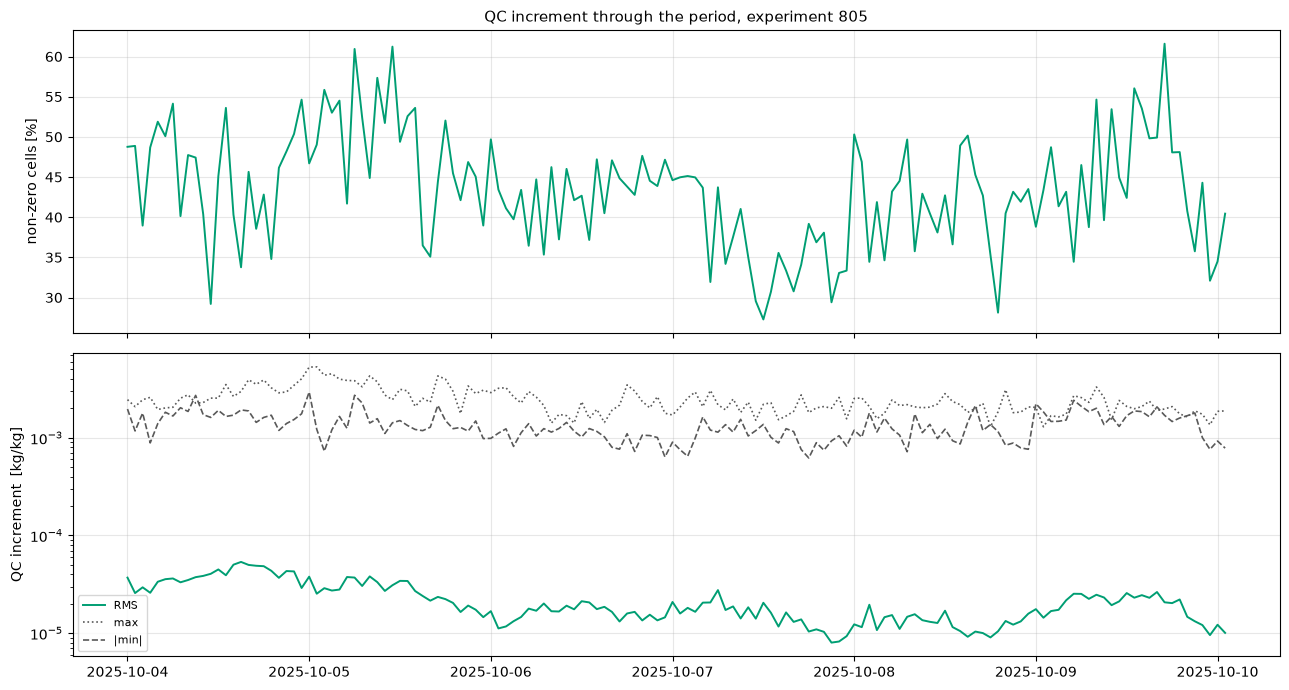

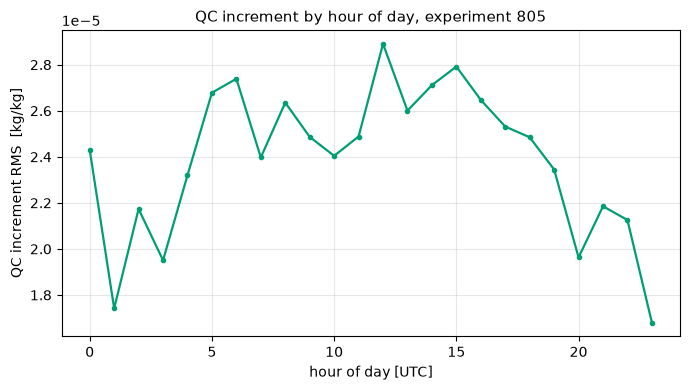

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(per_cycle.index, per_cycle["frac"] * 100, "-", color=EXP_COLOUR, lw=1.4)
axes[0].set_ylabel("non-zero cells [%]")
axes[0].set_title(f"QC increment through the period, experiment {EXP_ID}", fontsize=11)

axes[1].plot(per_cycle.index, per_cycle["rms"], "-", color=EXP_COLOUR, lw=1.4,
             label="RMS")
axes[1].plot(per_cycle.index, per_cycle["amax"], ":", color="0.35", lw=1.2,
             label="max")
axes[1].plot(per_cycle.index, -per_cycle["amin"], "--", color="0.35", lw=1.2,
             label="|min|")
axes[1].set_yscale("log")
axes[1].set_ylabel("QC increment  [kg/kg]")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
finish(fig, "qc_increment_timeseries.png")

# Diurnal composite: a cycle-time dependence would point at the assimilated screen-level
# observations rather than at a numerical artefact.
diurnal = stats.groupby("hour").agg(
    frac=("frac_nonzero_dom", "mean"),
    rms=("rms_dom", lambda s: np.sqrt((s ** 2).mean())),
    mean=("mean_dom", "mean"))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(diurnal.index, diurnal["rms"], "-o", color=EXP_COLOUR, lw=1.6, ms=3)
ax.set_xlabel("hour of day [UTC]")
ax.set_ylabel("QC increment RMS  [kg/kg]")
ax.set_title(f"QC increment by hour of day, experiment {EXP_ID}", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
finish(fig, "qc_increment_diurnal.png")

## 5. What to take from it

Read the section-3 numbers first:

- **every cycle identically zero** — the increment behaves as documented and whatever was
  seen elsewhere comes from a later step of the cycle (the initialized-analysis window, or
  the model's own saturation adjustment), not from the LETKF.
- **non-zero but at the packing step printed in section 1, with no vertical or diurnal
  structure** — a GRIB quantisation artefact, not a physical increment.
- **non-zero, structured in the vertical, and a non-trivial fraction of the first-guess
  QC RMS** — the LETKF really is writing cloud water, and the levels and hours where it
  does are the ones to carry back to the CLCT decomposition.